In [1]:
# automatically reload each function when called for development
%load_ext autoreload
%autoreload 2

In [2]:
from codes.PNGmodel import PNGmodel
from codes.MathModels import Y1, fNL_only
from codes.chain import chain
from codes.corner_plots import make_corner
from codes.helper_functions import *
from astropy.table import Table, vstack
import numpy as np
import pandas as pd

In [4]:
test = ['xi0', 'xi0','xi0', 'xi2', 'xi2', 'xi2', 'xi4', 'xi4', 'xi4']
terms = list(dict.fromkeys(test))

In [8]:
df0 = pd.read_csv('./inputs/quadfits_LRG_FastPM_Y3_fnl_xi0.csv')
df0['term'] = len(df0)*['xi0']
df2 = pd.read_csv('./inputs/quadfits_LRG_FastPM_Y3_fnl_xi2.csv')
df2['term'] = len(df0)*['xi2']
df4 = pd.read_csv('./inputs/quadfits_LRG_FastPM_Y3_fnl_xi4.csv')
df4['term'] = len(df0)*['xi4']

df = pd.concat([df4, df2, df0])
df = df.rename(columns={'Unnamed: 0': 's'})
df

,s,c1,c2,term
0,50.0,0.000000e+00,0.000000e+00,xi4
1,60.0,0.000000e+00,0.000000e+00,xi4
2,70.0,0.000000e+00,0.000000e+00,xi4
3,80.0,0.000000e+00,0.000000e+00,xi4
4,90.0,0.000000e+00,0.000000e+00,xi4
...,...,...,...,...
31,360.0,8.667759e-07,7.550525e-09,xi0
32,370.0,6.387427e-07,-1.918115e-09,xi0
33,380.0,5.414355e-07,2.951001e-09,xi0
34,390.0,5.800813e-07,1.503561e-08,xi0


In [10]:
terms = ['xi4', 'xi0','xi2']
df['term'] = pd.Categorical(df['term'], categories=terms, ordered=True)
df = df.sort_values(['term', 's']).reset_index(drop=True)
df

,s,c1,c2,term
0,50.0,0.000000e+00,0.0,xi4
1,60.0,0.000000e+00,0.0,xi4
2,70.0,0.000000e+00,0.0,xi4
3,80.0,0.000000e+00,0.0,xi4
4,90.0,0.000000e+00,0.0,xi4
...,...,...,...,...
103,360.0,-1.222665e-07,0.0,xi2
104,370.0,-1.157614e-07,0.0,xi2
105,380.0,-6.791730e-07,0.0,xi2
106,390.0,-3.760793e-07,0.0,xi2


Initializing...
Loading model coefficients...
	added attribute: c1
	added attribute: c2
Loading covariance matrix...
Observable will have 108 pts
Exploring parameter space...


100%|██████████| 2000/2000 [00:02<00:00, 687.15it/s]


fNL = -2.93 + 11.02 - 10.92


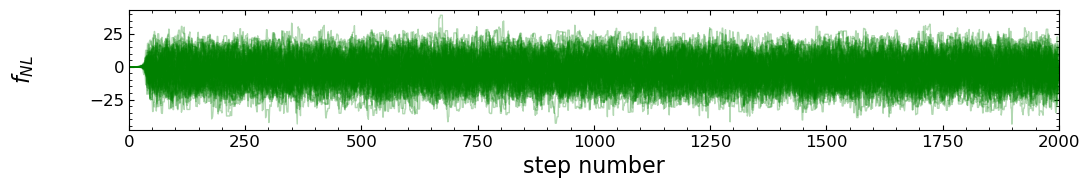

In [14]:
from codes.MathModels import fNL_only

mod = PNGmodel(fid_corr = './inputs/abacus_averaged_fiducial_wts_fixed.fits', 
               math_model = fNL_only())

mod.load_fits(file = './inputs/quadfits_LRG_FastPM_Y3_fnl.csv')

mod.load_covariance(cov_pkg = './inputs/EZ_mock_covariance_matrix.npy')

mod.run_sampling(min_type='data', # must be first argument
                 fname_chain=f'./outputs/testchain_fNL_only.txt', # must be second argument
                 data_obs = f'./inputs/Y1_LRG_correlations_v1.5_.fits', # must provide data if min_type='data'
                 nsteps = 2000, # Optional. Defaults to 20000, but set to 2000 for code testing
                )

In [12]:
type(set())

set

In [58]:
df = pd.read_csv('./inputs/quadfits_LRG_FastPM_Y3_fnl.csv')
terms = ['xi0', 'xi2', 'xi4']
temp = df.sort_values(by=['term','s'])
# temp = df.sort_values(by='s')
# temp = df.sort_values(by='term', key=lambda column: column.map(lambda e: terms.index(e)))
temp

,term,s,c1,c2
0,xi0,50.0,0.000033,-2.935762e-08
1,xi0,60.0,0.000026,-8.148258e-08
2,xi0,70.0,0.000021,-3.499445e-08
3,xi0,80.0,0.000017,6.198534e-08
4,xi0,90.0,0.000014,7.055060e-09
...,...,...,...,...
103,xi4,360.0,0.000000,0.000000e+00
104,xi4,370.0,0.000000,0.000000e+00
105,xi4,380.0,0.000000,0.000000e+00
106,xi4,390.0,0.000000,0.000000e+00


In [65]:
tab = Table.read('./inputs/abacus_averaged_fiducial_wts_fixed.fits')
print(tab[0])
rev = tab[['s', 'xi4','xi0','xi2']]
print(rev[0])
rev.write('./inputs/abacus_averaged_fiducial_wts_fixed_reversed.fits', format='fits', overwrite=True)

 s       xi0         xi2         xi4     
---- ----------- ----------- ------------
50.0 0.021023577 -0.02737209 0.0005588491
 s       xi4          xi0         xi2    
---- ------------ ----------- -----------
50.0 0.0005588491 0.021023577 -0.02737209


In [59]:
mod = PNGmodel(fid_corr = './inputs/abacus_averaged_fiducial_wts_fixed.fits', 
               math_model = Y1())

mod.load_PNG_model(files = './inputs/quadfits_LRG_FastPM_Y3_fnl.csv')

mod.load_covariance(cov_pkg = './inputs/EZ_mock_covariance_matrix.npy')

mod.load_photo_vary_fits(pkg_set1 = './inputs/quadfits_LRG_abacus_Y1_Ksys_SGC.csv',
                         pkg_set2 = './inputs/quadfits_LRG_abacus_Y1_Ksys_DEC.csv',
                         pkg_set3 = './inputs/quadfits_LRG_abacus_Y1_Ksys_MZLS.csv')

mod.run_sampling(min_type='data', # must be first argument
                 fname_chain=f'./outputs/testchain_new_prior.txt', # must be second argument
                 data_obs = f'./inputs/Y1_LRG_correlations_v1.5_.fits', # must provide data if min_type='data'
                 nsteps = 2000, # Optional. Defaults to 20000, but set to 2000 for code testing
                 update_priors = {'b1g':[1.90, 0.06, 'gauss']},
                 # Specify parameters that our MathModel needs
                 **{'z_eff': 0.780, 
                    'Om_m0_g': 0.315,
                    'z_fid': 0.776,
                    'z_halo': 0.787, 
                    'Om_m0_h': 0.3089,
                    # 'poi_hard_lims': ((-250,250),(0.5,4)),
                    # 'gauss_priors': ((1.94,0.04),(1.94,0.04),(1,0.1),(1,0.1)),
                    # 'Psys1_gauss_prior': (0,10),
                    # 'Psys2_gauss_prior': (0,10),
                    # 'Psys3_gauss_prior': (0,10)
                   }
                )

Initializing...
Loading PNG model...


PermissionError: [Errno 13] Permission denied: '.'

In [5]:
mod = PNGmodel(fid_corr = './inputs/abacus_averaged_fiducial_wts_fixed.fits', 
               math_model = Y1())

mod.load_covariance(cov_pkg = './inputs/EZ_mock_covariance_matrix.npy')

mod.load_fits('./inputs/quadfits_LRG_FastPM_Y3_fnl.csv')
mod.load_fits('./inputs/quadfits_LRG_abacus_Y1_Ksys_SGC.csv', mapper={'c1': 'pvar_par_B1', 'c2': 'pvar_par_A1'})
mod.load_fits('./inputs/quadfits_LRG_abacus_Y1_Ksys_SGC.csv', mapper={'c1': 'pvar_par_B2', 'c2': 'pvar_par_A2'})
mod.load_fits('./inputs/quadfits_LRG_abacus_Y1_Ksys_SGC.csv', mapper={'c1': 'pvar_par_B3', 'c2': 'pvar_par_A3'})

mod.run_sampling(min_type='data', # must be first argument
                 fname_chain=f'./outputs/testchain_loadfits.txt', # must be second argument
                 data_obs = f'./inputs/Y1_LRG_correlations_v1.5_.fits', # must provide data if min_type='data'
                 nsteps = 20000, # Optional. Defaults to 20000, but set to 2000 for code testing
                 # update_priors = {'b1g':[1.90, 0.06, 'gauss']},
                 # Specify parameters that our MathModel needs
                 **{'z_eff': 0.780, 
                    'Om_m0_g': 0.315,
                    'z_fid': 0.776,
                    'z_halo': 0.787, 
                    'Om_m0_h': 0.3089,
                    # 'poi_hard_lims': ((-250,250),(0.5,4)),
                    # 'gauss_priors': ((1.94,0.04),(1.94,0.04),(1,0.1),(1,0.1)),
                    # 'Psys1_gauss_prior': (0,10),
                    # 'Psys2_gauss_prior': (0,10),
                    # 'Psys3_gauss_prior': (0,10)
                   }
                )

Initializing...
Loading covariance matrix...
Loading model coefficients...
	added attribute: c1
	added attribute: c2
Loading model coefficients...
	added attribute: pvar_par_B1
	added attribute: pvar_par_A1
Loading model coefficients...
	added attribute: pvar_par_B2
	added attribute: pvar_par_A2
Loading model coefficients...
	added attribute: pvar_par_B3
	added attribute: pvar_par_A3
Observable will have 108 pts
Exploring parameter space...


Traceback (most recent call last):<01:12, 248.36it/s]
  File "/global/homes/h/hrandall/.conda/envs/myenv/lib/python3.14/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/global/u1/h/hrandall/Code_development/MCMC_chain_code/codes/PNGmodel.py", line 137, in log_probability_base_pars
    return 0.5*(lp + self.util_chi2_base_pars(params))
                     ~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^
  File "/global/u1/h/hrandall/Code_development/MCMC_chain_code/codes/PNGmodel.py", line 130, in util_chi2_base_pars
    return -np.matmul(np.matmul(self.masked['cov_inv'],(self.obs-exp)),(self.obs-exp))
                      ~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt
 10%|▉         | 1908/20000 [00:07<01:10, 257.71it/s]


emcee: Exception while calling your likelihood function:
  params: [ 24.5794883    1.83420789   1.91777983   1.94587342   0.96010339
   1.10262236   8.71511729 -11.44517377  -4.1042154 ]
  args: []
  kwargs: {}
  exception:


KeyboardInterrupt: 

In [ ]:
mod = PNGmodel(fid_corr = './inputs/abacus_averaged_fiducial_wts_fixed_reversed.fits', 
               math_model = Y1())
mod.load_covariance(cov_pkg = './inputs/EZ_mock_covariance_matrix.npy')

mod.load_fits('./inputs/quadfits_LRG_FastPM_Y3_fnl.csv')
mod.load_fits('./inputs/quadfits_LRG_abacus_Y1_Ksys_SGC.csv', mapper={'c1': 'pvar_par_B1', 'c2': 'pvar_par_A1'})
mod.load_fits('./inputs/quadfits_LRG_abacus_Y1_Ksys_SGC.csv', mapper={'c1': 'pvar_par_B2', 'c2': 'pvar_par_A2'})
mod.load_fits('./inputs/quadfits_LRG_abacus_Y1_Ksys_SGC.csv', mapper={'c1': 'pvar_par_B3', 'c2': 'pvar_par_A3'})

mod.run_sampling(min_type='data', # must be first argument
                 fname_chain=f'./outputs/testchain_loadfits.txt', # must be second argument
                 data_obs = f'./inputs/Y1_LRG_correlations_v1.5_.fits', # must provide data if min_type='data'
                 nsteps = 2000, # Optional. Defaults to 20000, but set to 2000 for code testing
                 # update_priors = {'b1g':[1.90, 0.06, 'gauss']},
                 # Specify parameters that our MathModel needs
                 **{'z_eff': 0.780, 
                    'Om_m0_g': 0.315,
                    'z_fid': 0.776,
                    'z_halo': 0.787, 
                    'Om_m0_h': 0.3089,
                    # 'poi_hard_lims': ((-250,250),(0.5,4)),
                    # 'gauss_priors': ((1.94,0.04),(1.94,0.04),(1,0.1),(1,0.1)),
                    # 'Psys1_gauss_prior': (0,10),
                    # 'Psys2_gauss_prior': (0,10),
                    # 'Psys3_gauss_prior': (0,10)
                   }
                )

In [53]:
og = PNGmodel(fid_corr = './inputs/abacus_averaged_fiducial_wts_fixed.fits', 
               math_model = Y1())

og.load_PNG_model(['./inputs/quadfits_LRG_FastPM_Y3_fnl_xi0.csv',
                                         './inputs/quadfits_LRG_FastPM_Y3_fnl_xi2.csv',
                                         './inputs/quadfits_LRG_FastPM_Y3_fnl_xi4.csv'])

og.load_covariance(cov_pkg = './inputs/EZ_mock_covariance_matrix.npy')

og.load_photo_vary_fits(pkg_set1 = ['./inputs/quadfits_LRG_abacus_Y1_Ksys_SGC_xi0.csv',
                                     './inputs/quadfits_LRG_abacus_Y1_Ksys_SGC_xi2.csv',
                                     './inputs/quadfits_LRG_abacus_Y1_Ksys_SGC_xi4.csv'],
                         pkg_set2 = ['./inputs/quadfits_LRG_abacus_Y1_Ksys_DEC_xi0.csv',
                                     './inputs/quadfits_LRG_abacus_Y1_Ksys_DEC_xi2.csv',
                                     './inputs/quadfits_LRG_abacus_Y1_Ksys_DEC_xi4.csv'],
                         pkg_set3 = ['./inputs/quadfits_LRG_abacus_Y1_Ksys_MZLS_xi0.csv',
                                     './inputs/quadfits_LRG_abacus_Y1_Ksys_MZLS_xi2.csv',
                                     './inputs/quadfits_LRG_abacus_Y1_Ksys_MZLS_xi4.csv'])


Initializing...
Loading PNG model...
Loading covariance matrix...
Loading systematic weight variation...


In [55]:
mod.c1

array([ 3.27647198e-05, -5.62006608e-07,  0.00000000e+00,  2.60600587e-05,
        3.66708264e-07,  0.00000000e+00,  2.11159699e-05, -4.58839349e-07,
        0.00000000e+00,  1.74011337e-05,  2.26986609e-07,  0.00000000e+00,
        1.38977251e-05, -5.29212411e-07,  0.00000000e+00,  1.22990983e-05,
       -2.20387010e-06,  0.00000000e+00,  1.08631619e-05, -1.68289989e-06,
        0.00000000e+00,  8.66323462e-06, -8.22334534e-07,  0.00000000e+00,
        7.38975577e-06, -4.92046820e-07,  0.00000000e+00,  6.41158695e-06,
        6.53095776e-07,  0.00000000e+00,  5.35137660e-06, -9.39820883e-07,
        0.00000000e+00,  4.27942578e-06, -1.56234310e-06,  0.00000000e+00,
        3.90209316e-06, -1.16075971e-06,  0.00000000e+00,  3.91271460e-06,
       -1.05721410e-06,  0.00000000e+00,  3.44995933e-06, -6.02120419e-07,
        0.00000000e+00,  3.10623800e-06, -1.25596418e-06,  0.00000000e+00,
        2.84198104e-06, -1.28911634e-06,  0.00000000e+00,  2.47424032e-06,
       -1.22777565e-06,  

In [85]:
priors = [(-250,250, 'flat'),
          (0.5,4, 'flat'),
          (1.94,0.04, 'gauss'),
          (1.94,0.04, 'gauss'),
          (1,0.1, 'gauss'),
          (1,0.1, 'gauss'),
          (0,10, 'gauss'), 
          (0,10, 'gauss'),
          (0,10, 'gauss')]

test_params = [20, 2.1, 2., 2.05, 1.01, 0.99, 3, -4, 10]

def log_prior(params):
    ...
    # Figure out how to make the priors less explicit so we can copy 
    # the same code for each of the different math models
    ...
    fNL, b1g, b1h, b1g_fid, ph, pg, Psys1, Psys2, Psys3 = params
    if priors[0][0] < fNL < priors[0][1] and \
        priors[1][0] < b1g < priors[1][1]:
        return -(Psys1-priors[6][0])**2/(priors[6][1])**2-\
        (Psys2-priors[7][0])**2/(priors[7][1])**2-\
        (Psys3-priors[8][0])**2/(priors[8][1])**2-\
        (b1h-priors[2][0])**2/(priors[2][1])**2-\
        (b1g_fid-priors[3][0])**2/(priors[3][1])**2-\
        (ph-priors[4][0])**2/(priors[4][1])**2-\
        (pg-priors[5][0])**2/(priors[5][1])**2
    return -np.inf

def flat(param, prior):
    if prior[0] < param < prior[1]:
        return 0
    return -np.inf
    
def gauss(param, prior):
    return -(param-prior[0])**2/(prior[1])**2

func_mapper = {'flat':flat, 'gauss':gauss}

def log_prior_mod(params):
    ...
    # Figure out how to make the priors less explicit so we can copy 
    # the same code for each of the different math models
    ...
    log_priors = np.asarray([func_mapper[priors[i][2]](p, priors[i]) for i,p in enumerate(params)])
    return np.sum(log_priors)

In [69]:
%timeit log_prior(test_params)

1.12 μs ± 4.87 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [47]:
%timeit log_prior_mod(test_params)

5.71 μs ± 14.2 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [58]:
import numpy as np
from collections import defaultdict

class LogPrior:
    def __init__(self, priors):
        """
        priors: list of tuples (low_or_mean, high_or_std, type_string)
        """
        groups = defaultdict(lambda: {"indices": [], "configs": []})
        for i, prior in enumerate(priors):
            groups[prior[2]]["indices"].append(i)
            groups[prior[2]]["configs"].append(prior)

        self._groups = [
            {
                "fn":      PRIOR_FUNCS[key],
                "indices": np.array(g["indices"]),
                # precompute config arrays once
                "p1":      np.array([c[0] for c in g["configs"]]),
                "p2":      np.array([c[1] for c in g["configs"]]),
            }
            for key, g in groups.items()
        ]

    def __call__(self, params):
        """Scalar call — params is 1D array, shape (ndim,)"""
        total = 0.0
        for g in self._groups:
            total += g["fn"](params[g["indices"]], g["p1"], g["p2"])
            # if total == -np.inf:
            #     return -np.inf   # early exit
        return total

    def vectorized(self, params):
        """Vectorized call — params is 2D array, shape (nwalkers, ndim)"""
        total = np.zeros(params.shape[0])
        for g in self._groups:
            contrib = g["fn"](
                params[:, g["indices"]],  # (nwalkers, n_in_group)
                g["p1"], g["p2"]
            )
            total += contrib
        return total

In [59]:
def log_gaussian(vals, means, sigmas):
    # works for vals shape (n,) or (nwalkers, n)
    return -0.5 * np.sum(((vals - means) / sigmas) ** 2, axis=-1)

def log_uniform(vals, lows, highs):
    inside = np.all((vals >= lows) & (vals <= highs), axis=-1)
    return np.where(inside, 0.0, -np.inf)

PRIOR_FUNCS = {
    "gauss": log_gaussian,
    "flat":  log_uniform,
}

In [60]:
lp = LogPrior(priors)
test_params_np = np.asarray(test_params)

%timeit lp(test_params_np)

12.7 μs ± 101 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [70]:
def compile_log_prior(priors):
    # Separate the two prior types at compile time
    gaussian_terms = [(i, p[0], p[1]) for i, p in enumerate(priors) if p[2] == "gauss"]
    uniform_terms  = [(i, p[0], p[1]) for i, p in enumerate(priors) if p[2] == "flat"]

    def log_prior(params):
        # Uniform bounds check first — cheapest early exit
        for i, low, high in uniform_terms:
            if not (low <= params[i] <= high):
                return -np.inf

        # Gaussian terms inlined — no function call overhead
        total = 0.0
        for i, mean, sigma in gaussian_terms:
            d = (params[i] - mean) / sigma
            total -= 0.5 * d * d

        return total

    return log_prior
lp = compile_log_prior(priors)

In [71]:
%timeit lp(test_params)

816 ns ± 4.16 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [96]:
mod = PNGmodel(fid_corr = './inputs/abacus_averaged_fiducial_wts_fixed.fits', 
               math_model = Y1())

mod.load_PNG_model(files = './inputs/quadfits_LRG_FastPM_Y3_fnl.csv')

mod.load_covariance(cov_pkg = './inputs/EZ_mock_covariance_matrix.npy')

mod.load_photo_vary_fits(pkg_set1 = './inputs/quadfits_LRG_abacus_Y1_Ksys_SGC.csv',
                         pkg_set2 = './inputs/quadfits_LRG_abacus_Y1_Ksys_DEC.csv',
                         pkg_set3 = './inputs/quadfits_LRG_abacus_Y1_Ksys_MZLS.csv')

Initializing...
Loading PNG model...
Loading covariance matrix...
Loading systematic weight variation...


Observable will have 108 pts

Exploring parameter space...


100%|██████████| 20000/20000 [01:25<00:00, 232.84it/s]


fNL = 5.23 + 12.32 - 12.57
b1g = 1.88 + 0.04 - 0.04
b1h = 1.94 + 0.04 - 0.04
b1gfid = 1.95 + 0.03 - 0.03
ph = 0.99 + 0.1 - 0.1
pg = 1.01 + 0.1 - 0.1
KsysSGC = 0.61 + 9.79 - 9.88
KsysDEC = 1.52 + 9.8 - 9.85
KsysMZLS = 0.42 + 9.82 - 9.83


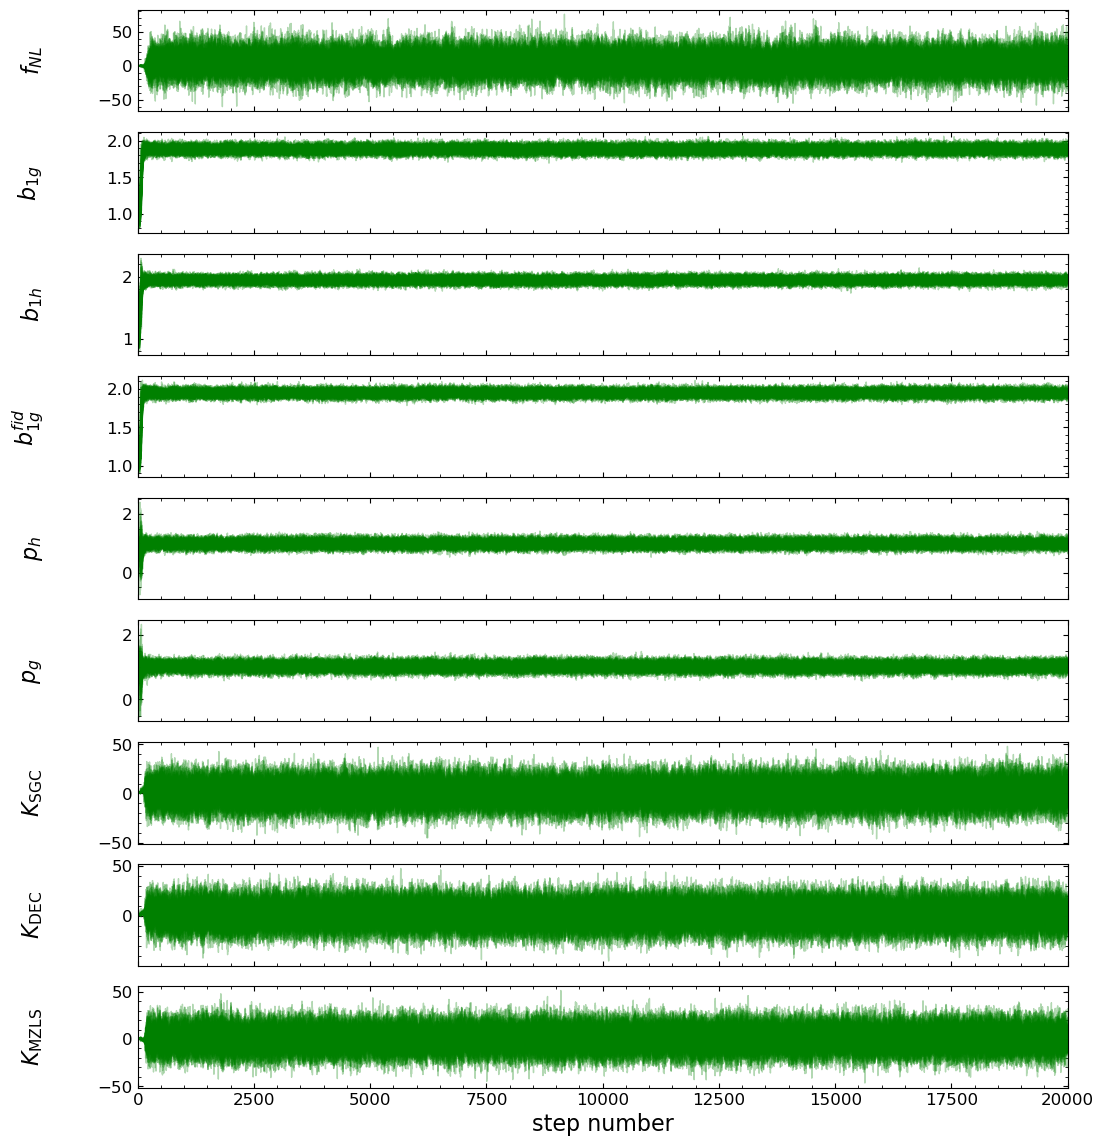

In [126]:
mod.run_sampling(min_type='data', # must be first argument
                 fname_chain=f'./outputs/testchain_new_prior.txt', # must be second argument
                 data_obs = f'./inputs/Y1_LRG_correlations_v1.5_.fits', # must provide data if min_type='data'
                 nsteps = 20000, # Optional. Defaults to 20000, but set to 2000 for code testing
                 update_priors = {'b1g':[1.90, 0.06, 'gauss']},
                 # Specify parameters that our MathModel needs
                 **{'z_eff': 0.780, 
                    'Om_m0_g': 0.315,
                    'z_fid': 0.776,
                    'z_halo': 0.787, 
                    'Om_m0_h': 0.3089,
                    # 'poi_hard_lims': ((-250,250),(0.5,4)),
                    # 'gauss_priors': ((1.94,0.04),(1.94,0.04),(1,0.1),(1,0.1)),
                    # 'Psys1_gauss_prior': (0,10),
                    # 'Psys2_gauss_prior': (0,10),
                    # 'Psys3_gauss_prior': (0,10)
                   }
                )

In [124]:
df = mod.parameter_info.copy()
df.at['b1g', 'prior'] = [2, 0.05, 'gauss']

df

,init,prior,plot_label,num_decimals,unit
key,,,,,
fNL,0,"[-250, 250, flat]",$f_{NL}$,0,
b1g,1,"[2, 0.05, gauss]",$b_{1g}$,2,
b1h,1,"[1.94, 0.04, gauss]",$b_{1h}$,2,
b1gfid,1,"[1.94, 0.04, gauss]",$b_{1g}^{fid}$,2,
ph,1,"[1, 0.1, gauss]",$p_h$,1,
pg,1,"[1, 0.1, gauss]",$p_g$,1,
KsysSGC,1,"[0, 10, gauss]",$K_{\mathrm{SGC}}$,1,\%
KsysDEC,1,"[0, 10, gauss]",$K_{\mathrm{DEC}}$,1,\%
KsysMZLS,1,"[0, 10, gauss]",$K_{\mathrm{MZLS}}$,1,\%


In [11]:
import yaml
colors = yaml.safe_load(open('./codes/config/colors.yaml'))

allowed_colors = list(colors.keys())

chain_colors = ['blue', None, 'green', None, None]
taken_colors = [x for x in chain_colors if x is not None]

leftover_colors = [x for x in allowed_colors if x not in taken_colors]

colors_keys = []
i = 0
for c in chains:
    if c.color is not None:
        color_keys.append(c.color)
    else:
        color_keys.append(leftover_colors[i])
        i += 1

['red', 'gray', 'orange', 'brown']